In [45]:
import sys
import os

# Get project ROOT (one level above /notebooks/)
project_root = os.path.abspath("..")
sys.path.append(project_root)

import importlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

import json
import joblib


In [46]:
with open("../saved_models/features.json") as f:
    feature_names = json.load(f)


In [47]:
df = pd.read_csv("../data/processed/final_dataset2.csv", parse_dates=["timestamp"])
df.head()


,timestamp,load_actual,temperature,humidity,dew_point,solar_generation,wind_generation
0,2014-12-31 23:00:00,9484.0,0.5,96.0,-0.1,92.66,734.81
1,2015-01-01 00:00:00,9484.0,0.1,95.0,-0.5,92.66,734.81
2,2015-01-01 01:00:00,9152.0,-0.2,95.0,-0.9,92.66,734.81
3,2015-01-01 02:00:00,8799.0,-0.4,95.0,-1.2,92.66,766.64
4,2015-01-01 03:00:00,8567.0,-0.6,95.0,-1.3,92.66,733.13


In [48]:
target = "load_actual"
X = df[feature_names]        # IMPORTANT
y = df[target]


In [49]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))


In [50]:
def create_sequences(X, y, lookback=24):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

lookback = 24
X_seq, y_seq = create_sequences(X_scaled, y_scaled, lookback)


In [51]:
train_size = int(len(X_seq) * 0.8)

X_train = X_seq[:train_size]
X_test  = X_seq[train_size:]

y_train = y_seq[:train_size]
y_test  = y_seq[train_size:]


In [52]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(lookback, X_train.shape[2])),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 24, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 0.0182 - val_loss: 0.0132
Epoch 2/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0135 - val_loss: 0.0135
Epoch 3/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0131 - val_loss: 0.0125
Epoch 4/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0127 - val_loss: 0.0126
Epoch 5/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0126 - val_loss: 0.0121
Epoch 6/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0124 - val_loss: 0.0118
Epoch 7/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0123 - val_loss: 0.0121
Epoch 8/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0122 - val_loss: 0.0119
Epoch 9/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0121 - val_loss: 0.0119
Epoch 10/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0120 - val_loss: 0.0122
Epoch 11/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0119 - val_loss: 0.0118
Epoch 12/20
1972/1

In [54]:
pred_scaled = model.predict(X_test)
pred = scaler_y.inverse_transform(pred_scaled)

y_test_actual = scaler_y.inverse_transform(y_test)


548/548 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [55]:
mae_lstm = mean_absolute_error(y_test_actual, pred)
rmse_lstm = mean_squared_error(y_test_actual, pred) ** 0.5
mape_lstm = np.mean(np.abs((y_test_actual - pred) / y_test_actual)) * 100

print("LSTM Results:")
print("MAE:", mae_lstm)
print("RMSE:", rmse_lstm)
print("MAPE:", mape_lstm)


LSTM Results:
MAE: 611.9069594471
RMSE: 765.541265360601
MAPE: 6.313711091830411


In [56]:
model.save("../saved_models/lstm_model.h5")
joblib.dump(scaler_X, "../saved_models/lstm_scaler_X.pkl")
joblib.dump(scaler_y, "../saved_models/lstm_scaler_y.pkl")


['../saved_models/lstm_scaler_y.pkl']

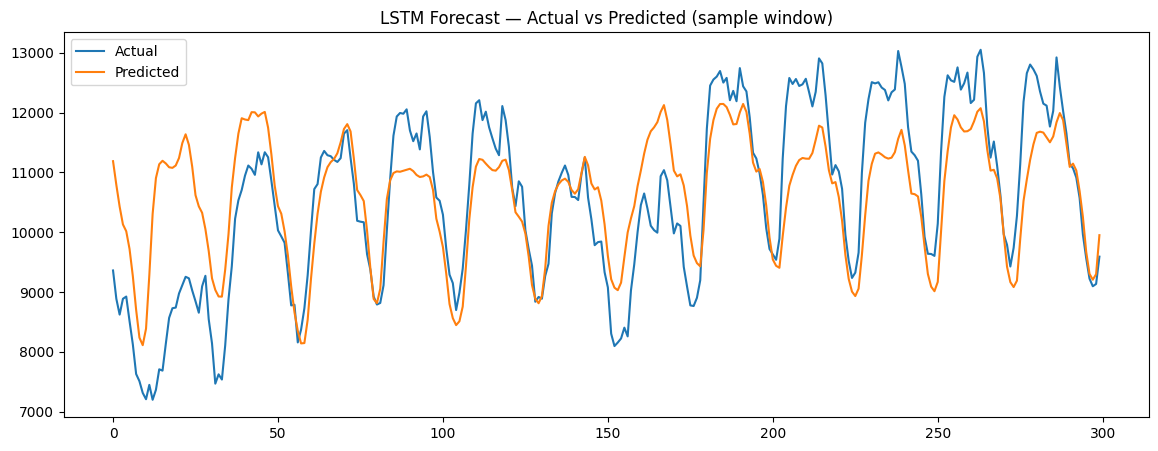

In [57]:
plt.figure(figsize=(14,5))
plt.plot(y_test_actual[:300], label="Actual")
plt.plot(pred[:300], label="Predicted")
plt.legend()
plt.title("LSTM Forecast — Actual vs Predicted (sample window)")
plt.show()
